# InceptionV3 para clasificacion de aves CUB-200-2011

Notebook simplificado de transfer learning con `InceptionV3`, siguiendo una estructura lineal similar al ejemplo de VGG: cargar datos, preparar datasets, definir modelo, entrenar, graficar y evaluar.


## 1. Importar librerias y configurar parametros


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


DATASET_NAME = "caltech_birds2011"
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.30

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Dataset cache:", TFDS_DATA_DIR)


2026-06-26 03:17:01.501089: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 03:17:02.716052: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-26 03:17:06.756731: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.


In [3]:
TRAIN_SPLIT = "train[:70%]"
VAL_SPLIT = "train[70%:]"
TEST_SPLIT = "test"

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

#Cantidad de clases y nombres de las clases
num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases: {num_classes}")
print(f"Train examples: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Validation examples: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Test examples: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")


Clases: 200
Train examples: 4196
Validation examples: 1798
Test examples: 5794


## 3. Visualizar algunas imagenes del dataset


In [ ]:
plt.figure(figsize=(12, 6))
for i, (image, label) in enumerate(ds_train_raw.take(6)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [4]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesar datos

CUB tiene imagenes de tamaños variables. Usamos `resize_with_pad` para llevarlas a `299x299` sin deformar la proporcion. Luego aplicamos `preprocess_input` de InceptionV3.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(image, label):
    image = tf.image.resize_with_pad(image, 299, 299)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    label = tf.cast(label, tf.int32)
    return image, label


def prepare_dataset(dataset, training=False):
    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=42, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch imagenes:", images.shape)
    print("Batch labels:", labels.shape)
    print("Label dtype:", labels.dtype)


2026-06-26 03:17:49.349230: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Batch imagenes: (16, 299, 299, 3)
Batch labels: (16,)
Label dtype: <dtype: 'int32'>


2026-06-26 03:17:52.109231: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 6. Definir el modelo base
Para iniciar con el transfer learning lo que hacemos es congelar todas las capas del Modelo preentrenado con el dataset de Imagenet, no incluimos su capa clasificadora. Agregamos nuestras capas finales propias que sirven para resolver el problema de clasificación que estamos abordando


In [6]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3),
)
base_model.trainable = False

inputs = layers.Input(shape=(299, 299, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name="InceptionV3")
model.summary()


Model: "InceptionV3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       409,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,212,584 (84.73 MB)

 Trainable params: 409,800 (1.56 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

## 7. Compilar y entrenar el modelo
Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`


Epoch 1/30


2026-06-26 03:18:44.101112: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f89b40032b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-26 03:18:44.101445: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-26 03:18:44.577856: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-26 03:18:48.454452: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-26 03:18:55.368324: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.08GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-26 03:19:09.51134

262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0150 - loss: 5.3535

2026-06-26 03:19:36.111960: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.96GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.0150 - loss: 5.3527

2026-06-26 03:20:10.102071: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.98GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


263/263 ━━━━━━━━━━━━━━━━━━━━ 106s 272ms/step - accuracy: 0.0307 - loss: 5.1459 - val_accuracy: 0.0779 - val_loss: 4.7533
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.1282 - loss: 4.4566 - val_accuracy: 0.1657 - val_loss: 4.2601
Epoch 3/30
  1/263 ━━━━━━━━━━━━━━━━━━━━ 7:36 2s/step - accuracy: 0.3750 - loss: 3.8581

2026-06-26 03:20:51.537077: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 17165056 bytes after encountering the first element of size 17165056 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step - accuracy: 0.2302 - loss: 3.9447 - val_accuracy: 0.2225 - val_loss: 3.8832
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step - accuracy: 0.3012 - loss: 3.5672 - val_accuracy: 0.2742 - val_loss: 3.5987
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step - accuracy: 0.3715 - loss: 3.2687 - val_accuracy: 0.3120 - val_loss: 3.3753
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 105ms/step - accuracy: 0.4090 - loss: 3.0172 - val_accuracy: 0.3315 - val_loss: 3.1926
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.4623 - loss: 2.8062 - val_accuracy: 0.3643 - val_loss: 3.0424
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 104ms/step - accuracy: 0.5076 - loss: 2.6235 - val_accuracy: 0.3899 - val_loss: 2.9117
Epoch 9/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 107ms/step - accuracy: 0.5305 - loss: 2.4687 - val_accuracy: 0.4077 - val_loss: 2.8088
Epoch 10/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 29s 107ms/step - accuracy: 0.5589 - loss: 2.3365 - va

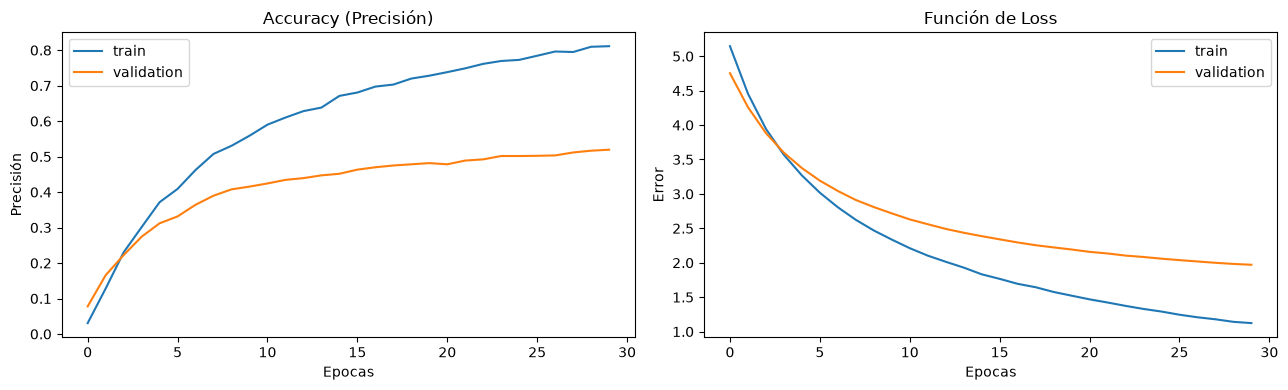

,accuracy,loss,val_accuracy,val_loss
0,0.030744,5.145888,0.077864,4.753300
1,0.128217,4.456550,0.165740,4.260124
2,0.230219,3.944719,0.222469,3.883226
3,0.301239,3.567220,0.274194,3.598697
4,0.371544,3.268670,0.312013,3.375262
5,0.408961,3.017232,0.331479,3.192615
6,0.462345,2.806205,0.364294,3.042434
7,0.507626,2.623472,0.389878,2.911747
8,0.530505,2.468745,0.407675,2.808820
9,0.558866,2.336462,0.415462,2.717304


In [7]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)


## 9. Evaluacion directa en conjunto de prueba


In [ ]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


## 10. Matriz de confusion y reporte de clasificacion


In [ ]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 11. Guardar resultados y modelo


In [ ]:
results = {
    "modelo": "InceptionV3",
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": 299,
    "batch_size": BATCH_SIZE,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history.history["loss"]),
    "learning_rate": LEARNING_RATE,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
    "test_top_5_accuracy": test_metrics[2],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / "inceptionv3_simple_results.csv"
model_path = MODELS_DIR / "inceptionv3_cub200.keras"

results_df.to_csv(results_path, index=False)
model.save(model_path)

print("Resultados guardados en:", results_path)
print("Modelo guardado en:", model_path)
